**Importamos librerías**

In [3]:
import pandas as pd

**Importamos Data a trabajar para cargar en DataSet:**



In [4]:
url="https://raw.githubusercontent.com/ccastaneda-boot/datamining/refs/heads/main/archivos/Prestige_modificado.csv"

In [5]:
df = pd.read_csv(url, sep=';')
df.head()

,occupation,education,income,women,prestige,census,type_num
0,gov.administrators,13.11,12351,11.16,68.8,1113,1
1,general.managers,12.26,25879,4.02,69.1,1130,1
2,accountants,12.77,9271,15.70,63.4,1171,1
3,purchasing.officers,11.42,8865,9.11,56.8,1175,1
4,chemists,14.62,8403,11.68,73.5,2111,1


**Datos generales:**

In [6]:
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())


(102, 7)
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.

**Analisis de relación entre variables:**

In [8]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

print(matriz_correlacion.round(3))
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))


           education  income  women  prestige  census  type_num
education      1.000   0.578  0.062     0.850  -0.823    -0.382
income         0.578   1.000 -0.441     0.715  -0.361    -0.368
women          0.062  -0.441  1.000    -0.118  -0.227     0.251
prestige       0.850   0.715 -0.118     1.000  -0.635    -0.465
census        -0.823  -0.361 -0.227    -0.635   1.000     0.288
type_num      -0.382  -0.368  0.251    -0.465   0.288     1.000
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


**Visualización de los resultados:**

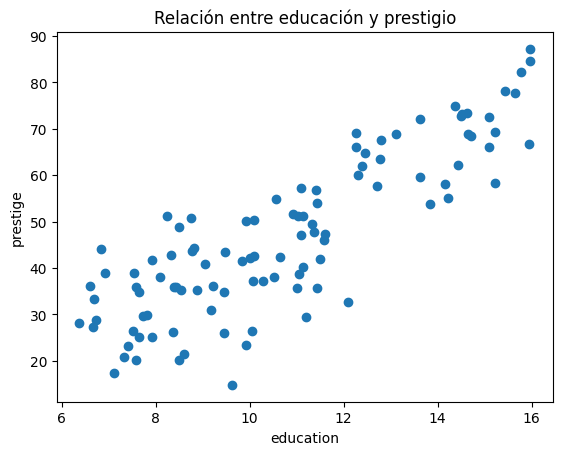

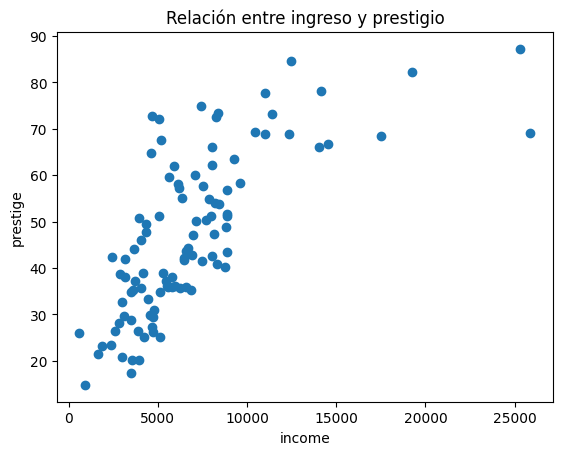

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['education'], df['prestige'])
plt.xlabel('education')
plt.ylabel('prestige')
plt.title('Relación entre educación y prestigio')
plt.show()

plt.figure()
plt.scatter(df['income'], df['prestige'])
plt.xlabel('income')
plt.ylabel('prestige')
plt.title('Relación entre ingreso y prestigio')
plt.show()


**Analisis de Agrupación de ocupaciones:**

           education    income  women  prestige  type_num
Cluster_4                                                
0              13.59   7329.35  36.35     63.33      0.95
1               8.82   5878.74   9.60     37.26      2.09
2              10.12   3545.04  74.16     37.76      2.57
3              14.69  15746.83   6.00     74.23      1.00
           education    income  women  prestige  type_num
Cluster_5                                                
0              10.94   3909.12  73.76     41.50      2.88
1               9.31   6922.03   5.84     42.18      2.25
2              13.59   7329.35  36.35     63.33      0.95
3               7.78   3327.48  34.10     26.87      1.71
4              14.69  15746.83   6.00     74.23      1.00


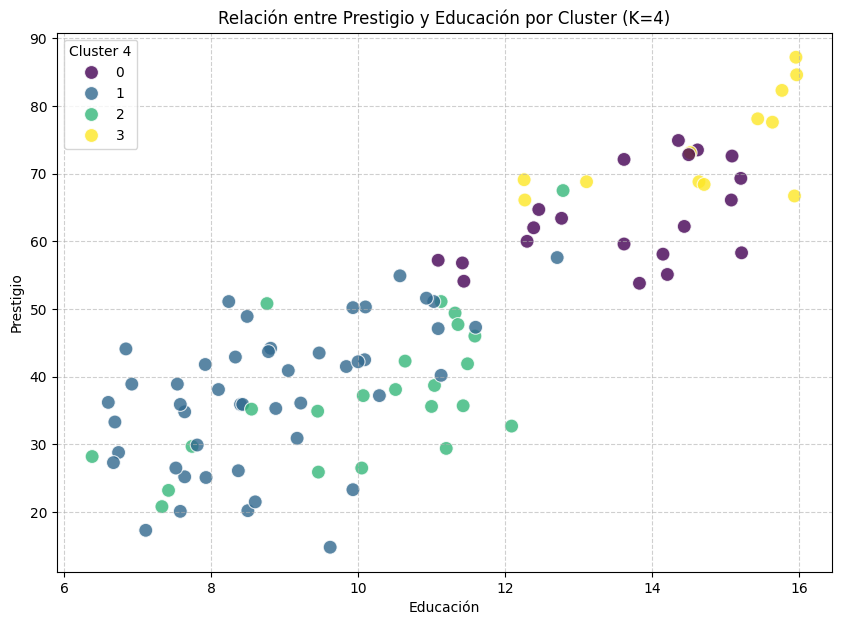

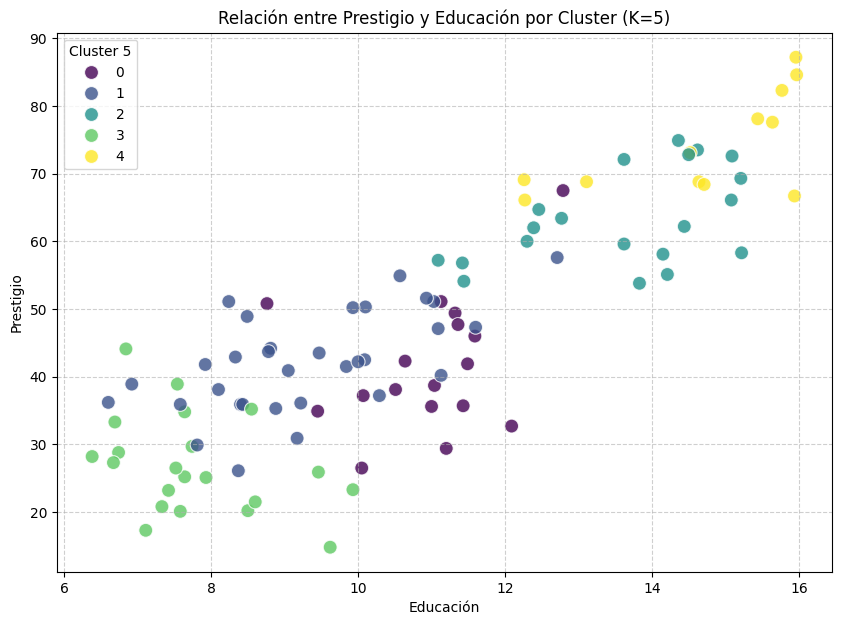

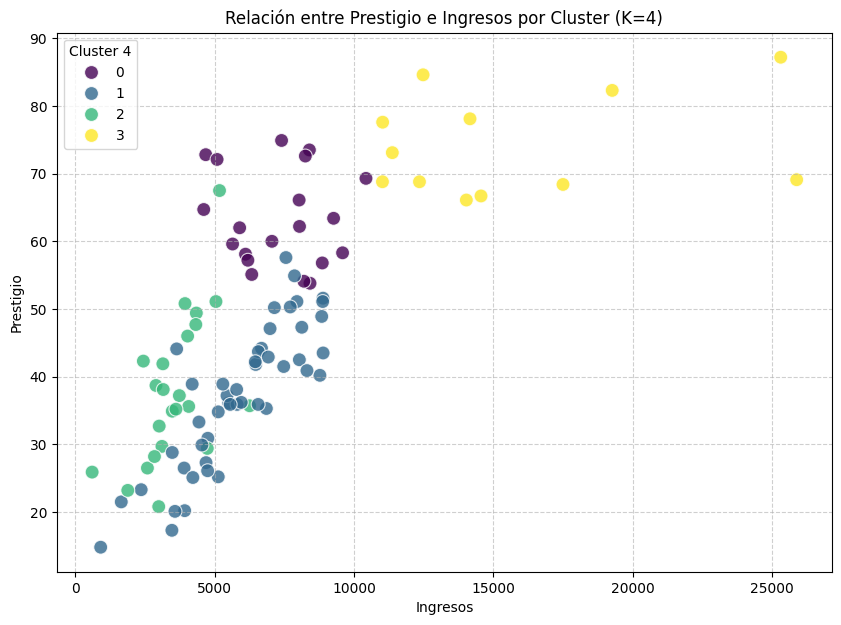

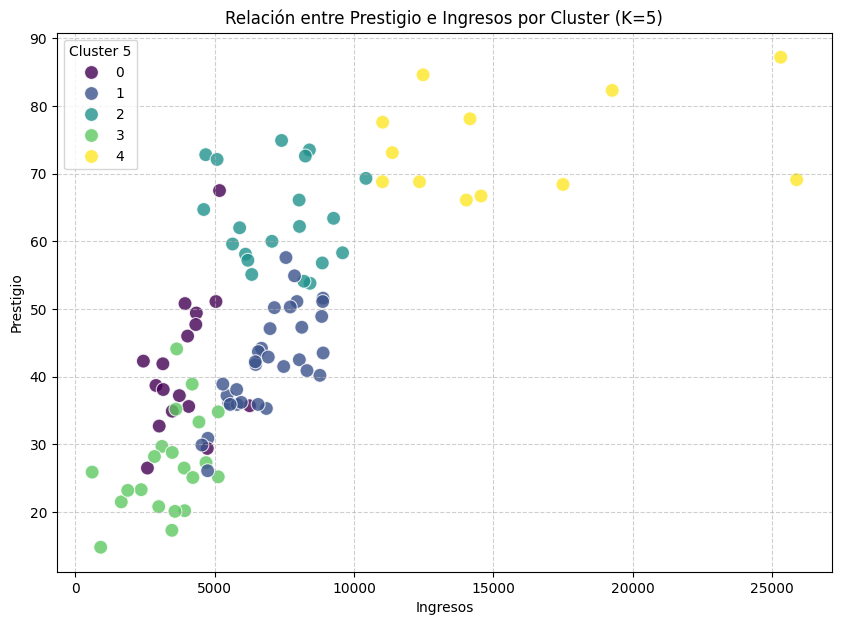

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

columnas_cluster = ['education', 'income', 'women', 'prestige', 'type_num']
X = df[columnas_cluster].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)

modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

print(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))
print(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='education', y='prestige', hue='Cluster_4', palette='viridis', s=100, alpha=0.8)
plt.title('Relación entre Prestigio y Educación por Cluster (K=4)')
plt.xlabel('Educación')
plt.ylabel('Prestigio')
plt.legend(title='Cluster 4')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='education', y='prestige', hue='Cluster_5', palette='viridis', s=100, alpha=0.8)
plt.title('Relación entre Prestigio y Educación por Cluster (K=5)')
plt.xlabel('Educación')
plt.ylabel('Prestigio')
plt.legend(title='Cluster 5')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='income', y='prestige', hue='Cluster_4', palette='viridis', s=100, alpha=0.8)
plt.title('Relación entre Prestigio e Ingresos por Cluster (K=4)')
plt.xlabel('Ingresos')
plt.ylabel('Prestigio')
plt.legend(title='Cluster 4')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='income', y='prestige', hue='Cluster_5', palette='viridis', s=100, alpha=0.8)
plt.title('Relación entre Prestigio e Ingresos por Cluster (K=5)')
plt.xlabel('Ingresos')
plt.ylabel('Prestigio')
plt.legend(title='Cluster 5')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

